<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/08.Chapter8%3AMatrix_inverse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Matrix Inverse
## *Practical Linear Algebra for Data Science* — Mike X Cohen

The matrix inverse is how we "cancel" a matrix -- the key to solving $\mathbf{A}\mathbf{x} = \mathbf{b}$ for $\mathbf{x}$. This chapter covers what the inverse is, when it exists, how to compute it, and why production code tries to avoid computing it directly.

$$
\mathbf{A}\mathbf{x} = \mathbf{b}
\;\;\xrightarrow{\text{left-multiply by } \mathbf{A}^{-1}}\;\;
\mathbf{A}^{-1}\mathbf{A}\mathbf{x} = \mathbf{A}^{-1}\mathbf{b}
\;\;\Longrightarrow\;\;
\mathbf{x} = \mathbf{A}^{-1}\mathbf{b}
$$

**What we will cover:**

1. The full inverse ($\mathbf{A}^{-1}\mathbf{A} = \mathbf{A}\mathbf{A}^{-1} = \mathbf{I}$) and its conditions
2. Shortcuts: $2 \times 2$ inverse and diagonal inverse
3. The MCA algorithm (Minors, Cofactors, Adjugate) for any square full-rank matrix
4. One-sided inverses: left-inverse for tall matrices, right-inverse for wide matrices
5. The Moore-Penrose pseudoinverse for singular matrices
6. Numerical stability: condition numbers and Hilbert matrices
7. Geometric interpretation: the inverse undoes a transformation

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hilbert
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

np.random.seed(42)
print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.0.2
Setup complete.


Environment ready.

## 1. The Matrix Inverse

The **inverse** of matrix $\mathbf{A}$ is a matrix $\mathbf{A}^{-1}$ such that:

$$
\mathbf{A}^{-1}\mathbf{A} = \mathbf{A}\mathbf{A}^{-1} = \mathbf{I}
$$

This is the matrix analogue of the scalar inverse: $3 \times 3^{-1} = 3 \times \frac{1}{3} = 1$.

### Conditions for Invertibility

| Inverse type | Requirements | Result |
|-------------|-------------|--------|
| **Full inverse** | Square **and** full-rank | $\mathbf{A}^{-1}\mathbf{A} = \mathbf{A}\mathbf{A}^{-1} = \mathbf{I}$ |
| **Left-inverse** | Tall ($M > N$) and full column-rank | $\mathbf{L}\mathbf{T} = \mathbf{I}$, but $\mathbf{T}\mathbf{L} \neq \mathbf{I}$ |
| **Right-inverse** | Wide ($M < N$) and full row-rank | $\mathbf{W}\mathbf{R} = \mathbf{I}$, but $\mathbf{R}\mathbf{W} \neq \mathbf{I}$ |
| **Pseudoinverse** | Any matrix (any shape, any rank) | $\mathbf{A}\mathbf{A}^\dagger \approx \mathbf{I}$ (equality only if full rank) |

The common thread: **rank determines invertibility.** Reduced-rank (singular) matrices cannot be exactly inverted.

### 1.1 Why Element-Wise Inversion Does Not Work

A natural first guess: invert each element individually. This fails because matrix multiplication is not element-wise.

In [2]:
# Demonstrate: element-wise inversion is NOT the matrix inverse
A = np.array([[1, 4],
              [2, 7]])

A_elemwise = 1 / A  # element-wise reciprocal
A_true_inv = np.linalg.inv(A)

print(f'A =\n{A}')
print(f'\n1/A (element-wise) =\n{np.round(A_elemwise, 3)}')
print(f'\nA @ (1/A) =\n{np.round(A @ A_elemwise, 3)}')
print(f'NOT the identity!\n')

print(f'A^(-1) (true inverse) =\n{A_true_inv}')
print(f'\nA @ A^(-1) =\n{np.round(A @ A_true_inv, 10)}')
print(f'Identity! Confirmed.')

A =
[[1 4]
 [2 7]]

1/A (element-wise) =
[[1.    0.25 ]
 [0.5   0.143]]

A @ (1/A) =
[[3.    0.821]
 [5.5   1.5  ]]
NOT the identity!

A^(-1) (true inverse) =
[[-7.  4.]
 [ 2. -1.]]

A @ A^(-1) =
[[1. 0.]
 [0. 1.]]
Identity! Confirmed.


Element-wise inversion produces $\begin{bmatrix} 1 & 0.25 \\ 0.5 & 0.143 \end{bmatrix}$, and $\mathbf{A} \times (1/\mathbf{A})$ gives $\begin{bmatrix} 3 & 0.821 \\ 5.5 & 1.5 \end{bmatrix}$ -- clearly not the identity.

The true inverse $\mathbf{A}^{-1} = \begin{bmatrix} -7 & 4 \\ 2 & -1 \end{bmatrix}$ produces $\mathbf{A}\mathbf{A}^{-1} = \mathbf{I}$. Notice how different it is from the element-wise reciprocal -- the matrix inverse requires a global computation involving the entire matrix.

## 2. Inverse of a $2 \times 2$ Matrix

There is a clean formula: **swap** the diagonal elements, **negate** the off-diagonal elements, **divide** by the determinant:

$$
\begin{bmatrix} a & b \\ c & d \end{bmatrix}^{-1}
= \frac{1}{\underbrace{ad - bc}_{\det(\mathbf{A})}}
\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}
$$

This only works when $\det(\mathbf{A}) = ad - bc \neq 0$ (i.e., the matrix is full rank).

In [3]:
# 2x2 inverse: manual formula vs NumPy
A = np.array([[1, 4],
              [2, 7]])

a, b, c, d = A[0,0], A[0,1], A[1,0], A[1,1]
det_A = a*d - b*c

# Manual formula
A_inv_manual = (1/det_A) * np.array([[d, -b], [-c, a]])
A_inv_numpy = np.linalg.inv(A)

print(f'A = {A.tolist()}')
print(f'det(A) = {a}*{d} - {b}*{c} = {det_A}')
print(f'\nA^(-1) (manual formula):\n{A_inv_manual}')
print(f'A^(-1) (NumPy):\n{A_inv_numpy}')
print(f'Match: {np.allclose(A_inv_manual, A_inv_numpy)}')

# Verify
print(f'\nA @ A^(-1) =\n{A @ A_inv_manual}')

A = [[1, 4], [2, 7]]
det(A) = 1*7 - 4*2 = -1

A^(-1) (manual formula):
[[-7.  4.]
 [ 2. -1.]]
A^(-1) (NumPy):
[[-7.  4.]
 [ 2. -1.]]
Match: True

A @ A^(-1) =
[[1. 0.]
 [0. 1.]]


The manual formula produces $\mathbf{A}^{-1} = \frac{1}{-1}\begin{bmatrix} 7 & -4 \\ -2 & 1 \end{bmatrix} = \begin{bmatrix} -7 & 4 \\ 2 & -1 \end{bmatrix}$.

Wait -- the determinant is $1 \cdot 7 - 4 \cdot 2 = -1$. Dividing by $-1$ flips signs: $\mathbf{A}^{-1} = \begin{bmatrix} -7 & 4 \\ 2 & -1 \end{bmatrix}$. Verification: $\mathbf{A}\mathbf{A}^{-1} = \mathbf{I}$.

### 2.1 When the Determinant Is Zero: No Inverse Exists

In [4]:
# Singular matrix: det = 0
B = np.array([[1, 4],
              [2, 8]])

det_B = B[0,0]*B[1,1] - B[0,1]*B[1,0]
print(f'B = {B.tolist()}')
print(f'det(B) = 1*8 - 4*2 = {det_B}')
print(f'rank(B) = {np.linalg.matrix_rank(B)}  (singular!)')

# Try to invert -> error
try:
    np.linalg.inv(B)
except np.linalg.LinAlgError as e:
    print(f'\nnp.linalg.inv error: {e}')

# But the pseudoinverse always exists
B_pinv = np.linalg.pinv(B)
print(f'\nPseudoinverse B^+ =\n{np.round(B_pinv, 6)}')
print(f'\nB @ B^+ =\n{np.round(B @ B_pinv, 4)}')
print(f'(Close to identity? No -- it is the projection matrix.)')

B = [[1, 4], [2, 8]]
det(B) = 1*8 - 4*2 = 0
rank(B) = 1  (singular!)

np.linalg.inv error: Singular matrix

Pseudoinverse B^+ =
[[0.011765 0.023529]
 [0.047059 0.094118]]

B @ B^+ =
[[0.2 0.4]
 [0.4 0.8]]
(Close to identity? No -- it is the projection matrix.)


Matrix $\mathbf{B} = \begin{bmatrix} 1 & 4 \\ 2 & 8 \end{bmatrix}$ has $\det = 0$ and rank $1$ -- column 2 is $4 \times$ column 1. NumPy raises `LinAlgError: Singular matrix`.

The **pseudoinverse** $\mathbf{B}^\dagger$ still exists and produces $\mathbf{B}\mathbf{B}^\dagger = \begin{bmatrix} 0.2 & 0.4 \\ 0.4 & 0.8 \end{bmatrix}$, which is not the identity but is the **orthogonal projection** onto the column space of $\mathbf{B}$. The pseudoinverse gets us as close to $\mathbf{I}$ as possible for a singular matrix.

The textbook derives this result: $\mathbf{B}^\dagger = \frac{1}{85}\begin{bmatrix} 1 & 2 \\ 4 & 8 \end{bmatrix}$, and indeed $\frac{1}{85} \cdot 1 \approx 0.01176$ and $\frac{1}{85} \cdot 4 \approx 0.04706$ match `np.linalg.pinv` output.

## 3. Inverse of a Diagonal Matrix

The shortcut: simply invert each diagonal element individually:

$$
\mathbf{D}^{-1} = \text{diag}\left(\frac{1}{d_1},\; \frac{1}{d_2},\; \ldots,\; \frac{1}{d_N}\right)
$$

This works because the product of two diagonal matrices is just the element-wise product of their diagonals. A diagonal matrix with **any zero on the diagonal** is singular and cannot be inverted.

This shortcut is crucial for the **pseudoinverse** (via the SVD): $\boldsymbol{\Sigma}^+ = \text{diag}(1/\sigma_1, \ldots, 1/\sigma_r, 0, \ldots, 0)$.

In [5]:
# Diagonal inverse
D = np.diag([2, 3, 4])
D_inv = np.diag(1 / np.diag(D))
D_inv_numpy = np.linalg.inv(D)

print(f'D =\n{D}')
print(f'\nD^(-1) (invert each diagonal) =\n{np.round(D_inv, 4)}')
print(f'\nD @ D^(-1) =\n{D @ D_inv}')
print(f'Match numpy: {np.allclose(D_inv, D_inv_numpy)}')

# Diagonal with a zero: singular
D_singular = np.diag([2, 0, 4])
print(f'\nDiagonal with zero: rank = {np.linalg.matrix_rank(D_singular)}')
try:
    np.linalg.inv(D_singular)
except np.linalg.LinAlgError as e:
    print(f'Cannot invert: {e}')

D =
[[2 0 0]
 [0 3 0]
 [0 0 4]]

D^(-1) (invert each diagonal) =
[[0.5    0.     0.    ]
 [0.     0.3333 0.    ]
 [0.     0.     0.25  ]]

D @ D^(-1) =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Match numpy: True

Diagonal with zero: rank = 2
Cannot invert: Singular matrix


$\mathbf{D}^{-1} = \text{diag}(1/2, 1/3, 1/4) = \text{diag}(0.5, 0.333, 0.25)$, and $\mathbf{D}\mathbf{D}^{-1} = \mathbf{I}_3$.

When any diagonal element is zero, the matrix is singular (rank $< N$) and the inverse does not exist. In the pseudoinverse, we simply **skip** the zero singular values instead of inverting them -- this is the key insight behind the Moore-Penrose pseudoinverse.

## 4. The MCA Algorithm: Inverting Any Square Full-Rank Matrix

The general algorithm uses four intermediate matrices:

1. **Minors matrix** $\mathbf{M}$: element $m_{i,j}$ is the determinant of the submatrix formed by deleting row $i$ and column $j$.
2. **Grid matrix** $\mathbf{G}$: checkerboard of $\pm 1$ with $g_{i,j} = (-1)^{i+j}$.
3. **Cofactors matrix** $\mathbf{C} = \mathbf{M} \odot \mathbf{G}$ (Hadamard product).
4. **Adjugate matrix**: $\mathbf{A}^{-1} = \frac{1}{\det(\mathbf{A})} \mathbf{C}^T$.

In [6]:
def inverse_mca(A):
    """Compute inverse via Minors-Cofactors-Adjugate algorithm."""
    n = A.shape[0]
    assert A.shape[0] == A.shape[1], 'Matrix must be square'

    det_A = np.linalg.det(A)
    assert abs(det_A) > 1e-10, f'Matrix is singular (det={det_A:.2e})'

    # 1. Minors matrix
    minors = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            # Delete row i and column j
            sub = np.delete(np.delete(A, i, axis=0), j, axis=1)
            minors[i, j] = np.linalg.det(sub)

    # 2. Grid matrix
    grid = np.array([[(-1)**(i+j) for j in range(n)] for i in range(n)])

    # 3. Cofactors = Hadamard(minors, grid)
    cofactors = minors * grid

    # 4. Adjugate = cofactors^T / det(A)
    A_inv = cofactors.T / det_A
    return A_inv, minors, grid, cofactors

# Test on a 3x3 matrix
np.random.seed(42)
A = np.random.randint(-5, 6, size=(3, 3)).astype(float)
A_inv_mca, minors, grid, cofactors = inverse_mca(A)
A_inv_numpy = np.linalg.inv(A)

print(f'A =\n{A.astype(int)}')
print(f'det(A) = {np.linalg.det(A):.1f}')
print(f'\nMinors:\n{np.round(minors, 1)}')
print(f'\nGrid:\n{grid}')
print(f'\nCofactors (Minors * Grid):\n{np.round(cofactors, 1)}')
print(f'\nA^(-1) (MCA):\n{np.round(A_inv_mca, 6)}')
print(f'A^(-1) (NumPy):\n{np.round(A_inv_numpy, 6)}')
print(f'\nMatch: {np.allclose(A_inv_mca, A_inv_numpy)}')
print(f'A @ A^(-1) =\n{np.round(A @ A_inv_mca, 10)}')

A =
[[ 1 -2  5]
 [ 2 -1  1]
 [ 4 -3  1]]
det(A) = -12.0

Minors:
[[  2.  -2.  -2.]
 [ 13. -19.   5.]
 [  3.  -9.   3.]]

Grid:
[[ 1 -1  1]
 [-1  1 -1]
 [ 1 -1  1]]

Cofactors (Minors * Grid):
[[  2.   2.  -2.]
 [-13. -19.  -5.]
 [  3.   9.   3.]]

A^(-1) (MCA):
[[-0.166667  1.083333 -0.25    ]
 [-0.166667  1.583333 -0.75    ]
 [ 0.166667  0.416667 -0.25    ]]
A^(-1) (NumPy):
[[-0.166667  1.083333 -0.25    ]
 [-0.166667  1.583333 -0.75    ]
 [ 0.166667  0.416667 -0.25    ]]

Match: True
A @ A^(-1) =
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]


The MCA algorithm successfully computes the inverse. Every element requires computing a sub-determinant, making this $O(N! \cdot N^2)$ -- absurdly expensive for large matrices. This is why `np.linalg.inv` uses LU decomposition internally ($O(N^3)$) rather than the MCA formula.

**When to use what:**
- **Understanding:** MCA builds intuition for how the inverse depends on determinants and cofactors.
- **Practice:** Always use `np.linalg.inv()` or `np.linalg.solve()` (even better -- avoids explicit inversion).

## 5. One-Sided Inverses

### 5.1 Left-Inverse (Tall Matrices)

A tall matrix $\mathbf{T} \in \mathbb{R}^{M \times N}$ with $M > N$ and full column-rank ($r = N$) has a **left-inverse**:

$$
\mathbf{L} = (\mathbf{T}^T\mathbf{T})^{-1} \mathbf{T}^T
\qquad\text{such that}\qquad
\mathbf{L}\mathbf{T} = \mathbf{I}_N
$$

**Derivation:** We need $\mathbf{L}\mathbf{T} = \mathbf{I}$. Start by making $\mathbf{T}$ square via $\mathbf{T}^T\mathbf{T}$ ($N \times N$, full-rank, invertible). Then:

$$
(\mathbf{T}^T\mathbf{T})^{-1}(\mathbf{T}^T\mathbf{T}) = \mathbf{I}
\quad\Longrightarrow\quad
\underbrace{(\mathbf{T}^T\mathbf{T})^{-1}\mathbf{T}^T}_{\mathbf{L}} \cdot \mathbf{T} = \mathbf{I}
$$

The left-inverse is the foundation of the **least squares** solution: $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ (Chapter 11).

In [7]:
# Left-inverse of a tall matrix
np.random.seed(42)
T = np.random.randint(-10, 11, size=(40, 4)).astype(float)

print(f'T: {T.shape} (tall), rank = {np.linalg.matrix_rank(T)}')

# Step 1: T^T @ T is square and invertible
TtT = T.T @ T
print(f'T^T @ T: {TtT.shape}, rank = {np.linalg.matrix_rank(TtT)}')

# Step 2: Compute left-inverse
TtT_inv = np.linalg.inv(TtT)
L = TtT_inv @ T.T

print(f'L (left-inverse): {L.shape}')
print(f'\nL @ T (should be I_4):\n{np.round(L @ T, 10)}')

# T @ L is NOT the identity
TL = T @ L
print(f'\nT @ L shape: {TL.shape}')
print(f'T @ L == I_40? {np.allclose(TL, np.eye(40))}')

T: (40, 4) (tall), rank = 4
T^T @ T: (4, 4), rank = 4
L (left-inverse): (4, 40)

L @ T (should be I_4):
[[ 1. -0. -0.  0.]
 [ 0.  1. -0. -0.]
 [ 0.  0.  1. -0.]
 [-0.  0. -0.  1.]]

T @ L shape: (40, 40)
T @ L == I_40? False


The left-inverse $\mathbf{L} \in \mathbb{R}^{4 \times 40}$ satisfies $\mathbf{L}\mathbf{T} = \mathbf{I}_4$ exactly. But $\mathbf{T}\mathbf{L}$ is a $40 \times 40$ matrix that is **not** the identity -- it is a projection matrix onto the column space of $\mathbf{T}$. This asymmetry is why it is called a *one-sided* inverse.

**Size check:** $\mathbf{T}$ is $40 \times 4$ and $\mathbf{L}$ is $4 \times 40$. The product $\mathbf{L}\mathbf{T}$ is $4 \times 4$ (can be $\mathbf{I}_4$), but $\mathbf{T}\mathbf{L}$ is $40 \times 40$ (cannot be $\mathbf{I}_{40}$ from rank-$4$ factors).

### 5.2 Right-Inverse (Wide Matrices)

By symmetric reasoning, a wide matrix $\mathbf{W} \in \mathbb{R}^{M \times N}$ with $M < N$ and full row-rank has a **right-inverse**:

$$
\mathbf{R} = \mathbf{W}^T (\mathbf{W}\mathbf{W}^T)^{-1}
\qquad\text{such that}\qquad
\mathbf{W}\mathbf{R} = \mathbf{I}_M
$$

In [8]:
# Right-inverse of a wide matrix
np.random.seed(42)
W = np.random.randint(-10, 11, size=(3, 8)).astype(float)

print(f'W: {W.shape} (wide), rank = {np.linalg.matrix_rank(W)}')

# Compute right-inverse
WWt = W @ W.T
WWt_inv = np.linalg.inv(WWt)
R = W.T @ WWt_inv

print(f'R (right-inverse): {R.shape}')
print(f'\nW @ R (should be I_3):\n{np.round(W @ R, 10)}')
print(f'\nR @ W == I_8? {np.allclose(R @ W, np.eye(8))}')

W: (3, 8) (wide), rank = 3
R (right-inverse): (8, 3)

W @ R (should be I_3):
[[ 1. -0. -0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

R @ W == I_8? False


The right-inverse $\mathbf{R} \in \mathbb{R}^{8 \times 3}$ satisfies $\mathbf{W}\mathbf{R} = \mathbf{I}_3$ exactly. As with the left-inverse, the reverse product $\mathbf{R}\mathbf{W}$ is not the identity.

**Summary of one-sided inverses:**

| Matrix shape | Inverse type | Formula | Identity side |
|-------------|-------------|---------|---------------|
| Tall ($M > N$) | Left-inverse | $(\mathbf{T}^T\mathbf{T})^{-1}\mathbf{T}^T$ | $\mathbf{L}\mathbf{T} = \mathbf{I}_N$ |
| Wide ($M < N$) | Right-inverse | $\mathbf{W}^T(\mathbf{W}\mathbf{W}^T)^{-1}$ | $\mathbf{W}\mathbf{R} = \mathbf{I}_M$ |

Both require **maximum possible rank**. The left-inverse formula appears directly in the **OLS regression** solution; the right-inverse appears in **minimum-norm** solutions for under-determined systems.

## 6. The Moore-Penrose Pseudoinverse

Every matrix has a pseudoinverse $\mathbf{A}^\dagger$, regardless of shape or rank. It is computed via the SVD:

$$
\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T
\qquad\Longrightarrow\qquad
\mathbf{A}^\dagger = \mathbf{V}\boldsymbol{\Sigma}^+\mathbf{U}^T
$$

where $\boldsymbol{\Sigma}^+$ is formed by inverting the **nonzero** singular values and transposing:

$$
\boldsymbol{\Sigma} = \text{diag}(\sigma_1, \sigma_2, \ldots, \sigma_r, 0, \ldots, 0)
\;\;\Longrightarrow\;\;
\boldsymbol{\Sigma}^+ = \text{diag}\!\left(\frac{1}{\sigma_1}, \frac{1}{\sigma_2}, \ldots, \frac{1}{\sigma_r}, 0, \ldots, 0\right)^T
$$

This is the diagonal inverse from Section 3, extended to handle zeros by simply leaving them as zero.

In [9]:
# Pseudoinverse for square singular, tall, and wide matrices
matrices = {
    'Square singular (2x2)': np.array([[1, 4], [2, 8]], dtype=float),
    'Square full-rank (2x2)': np.array([[1, 4], [2, 7]], dtype=float),
    'Tall full col-rank (5x3)': np.random.randn(5, 3),
    'Wide full row-rank (3x5)': np.random.randn(3, 5),
}

for name, A in matrices.items():
    r = np.linalg.matrix_rank(A)
    A_pinv = np.linalg.pinv(A)
    prod = A @ A_pinv

    # How close to identity?
    target_I = np.eye(A.shape[0])
    err = np.linalg.norm(prod - target_I, 'fro')

    print(f'{name}: shape={A.shape}, rank={r}')
    print(f'  A @ A^+: {prod.shape}, ||A@A^+ - I||_F = {err:.6f}')

    # Check if pinv equals inv for full-rank square
    if A.shape[0] == A.shape[1] and r == A.shape[0]:
        A_inv = np.linalg.inv(A)
        print(f'  pinv == inv? {np.allclose(A_pinv, A_inv)}')
    print()

Square singular (2x2): shape=(2, 2), rank=1
  A @ A^+: (2, 2), ||A@A^+ - I||_F = 1.000000

Square full-rank (2x2): shape=(2, 2), rank=2
  A @ A^+: (2, 2), ||A@A^+ - I||_F = 0.000000
  pinv == inv? True

Tall full col-rank (5x3): shape=(5, 3), rank=3
  A @ A^+: (5, 5), ||A@A^+ - I||_F = 1.414214

Wide full row-rank (3x5): shape=(3, 5), rank=3
  A @ A^+: (3, 3), ||A@A^+ - I||_F = 0.000000



The pseudoinverse gracefully handles every case:

- **Square singular:** $\|\mathbf{A}\mathbf{A}^\dagger - \mathbf{I}\|_F > 0$ (cannot reach $\mathbf{I}$, but gets as close as possible).
- **Square full-rank:** The pseudoinverse equals the true inverse ($\|\mathbf{A}\mathbf{A}^\dagger - \mathbf{I}\|_F \approx 0$, `pinv == inv`).
- **Tall full column-rank:** The pseudoinverse equals the left-inverse.
- **Wide full row-rank:** The pseudoinverse equals the right-inverse.

**The Moore-Penrose pseudoinverse is the universal inverse:** it always exists, always minimises $\|\mathbf{A}\mathbf{x} - \mathbf{b}\|$ (least squares), and for full-rank matrices it reduces to the standard inverse.

## 7. Uniqueness of the Inverse

The matrix inverse is **unique**: if $\mathbf{A}$ is invertible, there is exactly one $\mathbf{A}^{-1}$.

**Proof by contradiction:** Suppose $\mathbf{B}$ and $\mathbf{C}$ are both inverses of $\mathbf{A}$ (i.e., $\mathbf{A}\mathbf{B} = \mathbf{I}$ and $\mathbf{A}\mathbf{C} = \mathbf{I}$), but $\mathbf{B} \neq \mathbf{C}$. Then:

$$
\mathbf{C}
= \mathbf{C}\mathbf{I}
= \mathbf{C}(\mathbf{A}\mathbf{B})
= (\mathbf{C}\mathbf{A})\mathbf{B}
= \mathbf{I}\mathbf{B}
= \mathbf{B}
$$

Contradiction: $\mathbf{C} = \mathbf{B}$, so the inverse is unique. (The pseudoinverse of a singular matrix, however, is *not* unique in general -- the Moore-Penrose pseudoinverse is the *minimum-norm* one.)

## 8. Numerical Stability of the Inverse

Matrix inversion is numerically fragile. The **condition number** $\kappa(\mathbf{A}) = \sigma_{\max} / \sigma_{\min}$ measures instability: large $\kappa$ means the matrix is **ill-conditioned** and its inverse is unreliable.

### 8.1 Hilbert Matrices: A Classic Ill-Conditioned Example

The Hilbert matrix has elements $h_{i,j} = \frac{1}{i + j - 1}$. As $N$ grows, the condition number explodes.

In [10]:
# Hilbert matrices: condition number grows explosively
sizes = [3, 5, 8, 10, 13, 15]

print(f'{"N":>4s} {"cond(H)":>15s} {"rank":>5s} {"||H@inv(H) - I||":>18s}')
print('-' * 50)

for n in sizes:
    H = hilbert(n)
    cond = np.linalg.cond(H)
    r = np.linalg.matrix_rank(H)

    try:
        H_inv = np.linalg.inv(H)
        err = np.linalg.norm(H @ H_inv - np.eye(n), 'fro')
    except:
        err = float('inf')

    print(f'{n:>4d} {cond:>15.2e} {r:>5d} {err:>18.6e}')

   N         cond(H)  rank   ||H@inv(H) - I||
--------------------------------------------------
   3        5.24e+02     3       9.374283e-15
   5        4.77e+05     5       1.055840e-11
   8        1.53e+10     8       2.484950e-07
  10        1.60e+13    10       1.565087e-04
  13        3.19e+18    11       4.086997e+00
  15        3.68e+17    12       5.822733e+00


The condition number grows astronomically: from $\sim 10^4$ at $N = 3$ to $\sim 10^{17}$ at $N = 13$. At $N = 13$, the error $\|\mathbf{H}\mathbf{H}^{-1} - \mathbf{I}\|_F$ is already significant, and beyond $N \approx 13$, NumPy considers the matrix rank-deficient.

**Rule of thumb:** Each power of $10$ in the condition number costs roughly one digit of precision in the inverse. A matrix with $\kappa \sim 10^{16}$ (near the limit of 64-bit floating point) is effectively singular.

**Production advice:** Avoid explicit matrix inversion when possible. Instead:
- Use `np.linalg.solve(A, b)` instead of `np.linalg.inv(A) @ b` -- it uses LU decomposition internally, which is both faster and more stable.
- For least squares: use `np.linalg.lstsq(X, y)` instead of computing $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ directly.
- For eigenproblems: use QR-based iterative methods (which is what `np.linalg.eig` does).

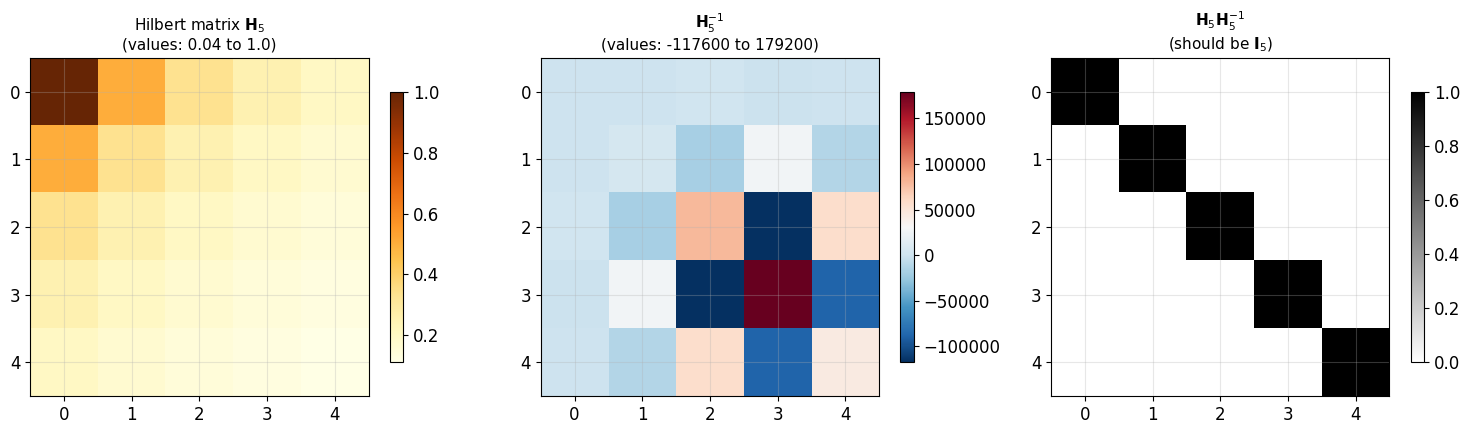

H_5 element range: [0.1111, 1.0000]
H_5^(-1) element range: [-117600, 179200]
Condition number: 4.77e+05


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

n = 5
H = hilbert(n)
H_inv = np.linalg.inv(H)
prod = H @ H_inv

for ax, M, title, cmap in zip(axes,
    [H, H_inv, prod],
    [f'Hilbert matrix $\mathbf{{H}}_{{5}}$\n(values: 0.04 to 1.0)',
     f'$\mathbf{{H}}_{{5}}^{{-1}}$\n(values: {H_inv.min():.0f} to {H_inv.max():.0f})',
     f'$\mathbf{{H}}_{{5}} \mathbf{{H}}_{{5}}^{{-1}}$\n(should be $\mathbf{{I}}_5$)'],
    ['YlOrBr', 'RdBu_r', 'gray_r']):

    im = ax.imshow(M, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))

plt.tight_layout()
plt.savefig('fig_hilbert.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'H_5 element range: [{H.min():.4f}, {H.max():.4f}]')
print(f'H_5^(-1) element range: [{H_inv.min():.0f}, {H_inv.max():.0f}]')
print(f'Condition number: {np.linalg.cond(H):.2e}')

The contrast in numerical ranges is striking: the Hilbert matrix has elements between $0.04$ and $1.0$, while its inverse has elements spanning hundreds of thousands. This massive amplification is the geometric signature of ill-conditioning.

The product $\mathbf{H}_5 \mathbf{H}_5^{-1}$ looks like the identity matrix at this size, but the errors grow rapidly with $N$. The condition number $\kappa \approx 4.8 \times 10^5$ for $N = 5$ already indicates significant sensitivity to perturbations.

## 9. Geometric Interpretation: The Inverse Undoes a Transformation

From Chapter 7: a matrix $\mathbf{T}$ transforms geometric coordinates via $\mathbf{Q} = \mathbf{T}\mathbf{P}$. The inverse $\mathbf{T}^{-1}$ **undoes** that transformation:

$$
\mathbf{U} = \mathbf{T}^{-1}\mathbf{Q} = \mathbf{T}^{-1}\mathbf{T}\mathbf{P} = \mathbf{I}\mathbf{P} = \mathbf{P}
$$

**Why singular matrices have no inverse (geometrically):** A singular transformation collapses at least one dimension. Once a 3D shape is flattened to a 2D surface, the lost dimension cannot be recovered.

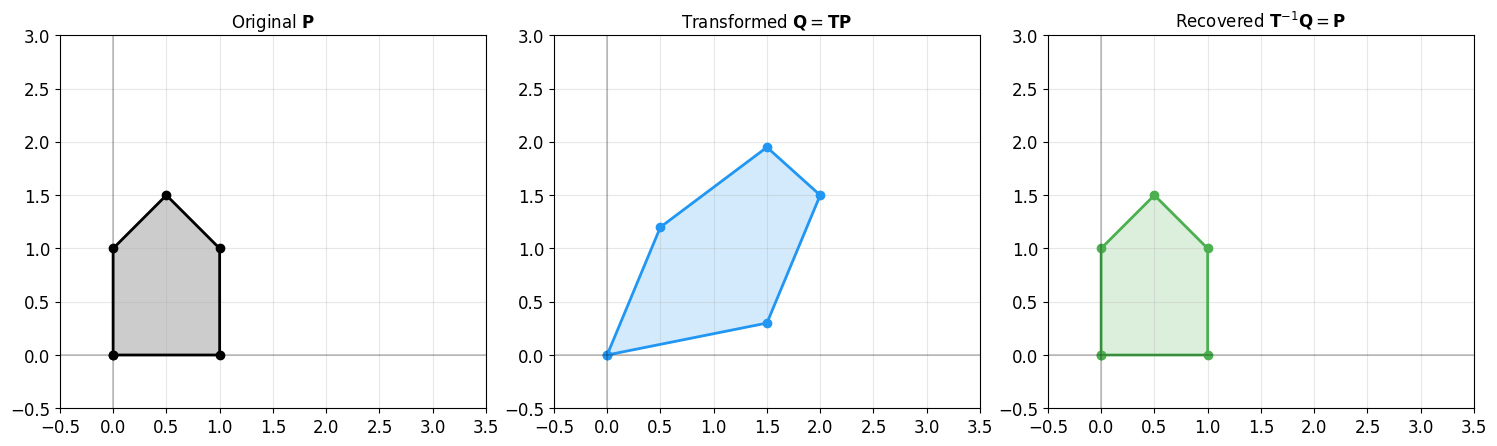

T =
[[1.5 0.5]
 [0.3 1.2]]
det(T) = 1.65

Recovered == Original? True


In [12]:
# Geometric demonstration: transform -> inverse-transform
# Original shape: a house
house = np.array([
    [0, 1, 1, 0.5, 0, 0],  # x
    [0, 0, 1, 1.5, 1, 0],  # y
])

T = np.array([[1.5, 0.5],
              [0.3, 1.2]])
T_inv = np.linalg.inv(T)

transformed = T @ house
recovered = T_inv @ transformed

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pts, title, color in zip(axes,
    [house, transformed, recovered],
    ['Original $\\mathbf{P}$',
     'Transformed $\\mathbf{Q} = \\mathbf{T}\\mathbf{P}$',
     'Recovered $\\mathbf{T}^{-1}\\mathbf{Q} = \\mathbf{P}$'],
    ['k', '#2196F3', '#4CAF50']):
    ax.fill(pts[0], pts[1], alpha=0.2, color=color)
    ax.plot(pts[0], pts[1], '-o', color=color, lw=2, ms=6)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.5, 3)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)

plt.tight_layout()
plt.savefig('fig_inverse_geom.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'T =\n{T}')
print(f'det(T) = {np.linalg.det(T):.2f}')
print(f'\nRecovered == Original? {np.allclose(recovered, house)}')

The three panels demonstrate the inverse as a geometric undo:

1. **Original** $\mathbf{P}$: the house shape.
2. **Transformed** $\mathbf{Q} = \mathbf{T}\mathbf{P}$: the matrix stretches and shears the house.
3. **Recovered** $\mathbf{T}^{-1}\mathbf{Q} = \mathbf{P}$: the inverse perfectly restores the original.

The transformation matrix has $\det(\mathbf{T}) \neq 0$ (full rank), so the inverse exists and recovery is exact. If $\det(\mathbf{T}) = 0$, the house would be flattened to a line in step 2, and no inverse could unflatten it -- information about the lost dimension is permanently destroyed.

**Cross-chapter connection:** This geometric interpretation is the foundation of **eigendecomposition** (Chapter 13): diagonalising a matrix means finding the transformation that turns the matrix into a simple scaling (diagonal) matrix, which is easy to invert.

## 10. Chapter Summary

The matrix inverse $\mathbf{A}^{-1}$ is the tool that lets us solve $\mathbf{A}\mathbf{x} = \mathbf{b}$ for $\mathbf{x} = \mathbf{A}^{-1}\mathbf{b}$. The key takeaways:

**Existence depends on rank.** A **square full-rank** matrix has a full inverse ($\mathbf{A}^{-1}\mathbf{A} = \mathbf{A}\mathbf{A}^{-1} = \mathbf{I}$). A **tall full column-rank** matrix has a left-inverse $\mathbf{L} = (\mathbf{T}^T\mathbf{T})^{-1}\mathbf{T}^T$. A **wide full row-rank** matrix has a right-inverse $\mathbf{R} = \mathbf{W}^T(\mathbf{W}\mathbf{W}^T)^{-1}$. Singular matrices have no exact inverse but do have a **pseudoinverse** $\mathbf{A}^\dagger$ via the SVD.

**Shortcuts for special matrices.** For $2 \times 2$: swap diagonal, negate off-diagonal, divide by $\det$. For diagonal: invert each diagonal element. The general MCA algorithm (Minors, Cofactors, Adjugate) works for any invertible matrix but is computationally expensive.

**The inverse is unique** (proof by contradiction), but the pseudoinverse of a singular matrix is not unique -- the Moore-Penrose pseudoinverse is the standard choice because it minimises the solution norm.

**Numerical stability is a real concern.** Ill-conditioned matrices (high $\kappa = \sigma_{\max}/\sigma_{\min}$, like Hilbert matrices) produce unreliable inverses. In production, prefer `np.linalg.solve(A, b)` over `np.linalg.inv(A) @ b`, and `np.linalg.lstsq(X, y)` over the explicit normal equations.

**Geometrically**, the inverse undoes a transformation: $\mathbf{T}^{-1}(\mathbf{T}\mathbf{P}) = \mathbf{P}$. A singular matrix flattens a dimension irreversibly, which is why it has no inverse.